Saving AB_NYC_2019.csv.zip to AB_NYC_2019.csv.zip
Dataset Loaded Successfully
Shape: (48895, 16)
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  

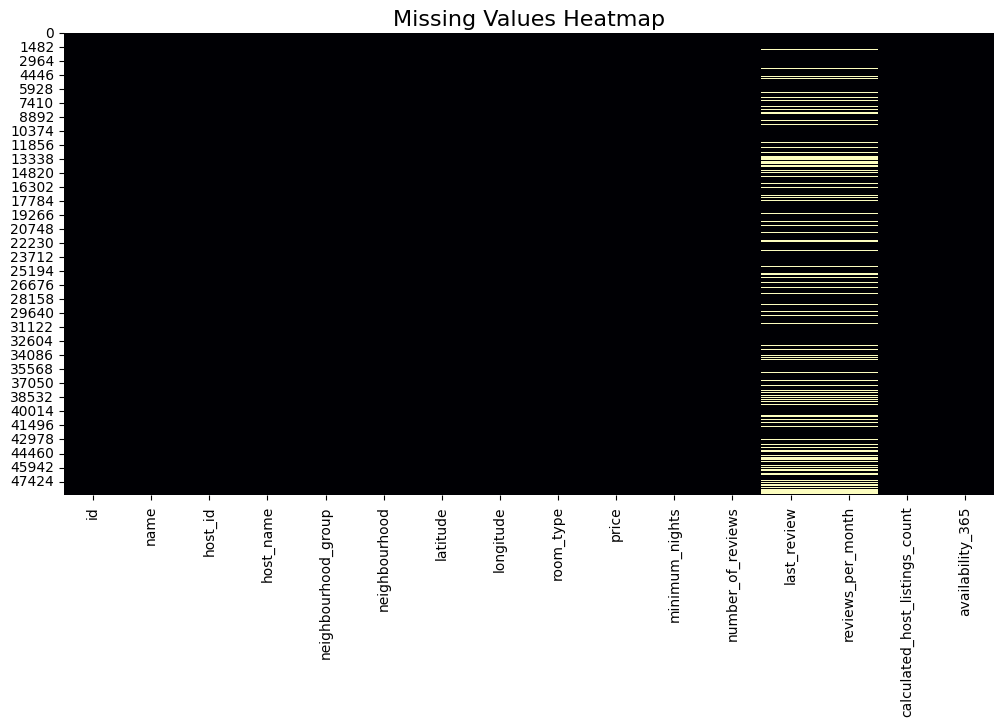

/tmp/ipykernel_1234/2446307303.py:70: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_1234/2446307303.py:75: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' 

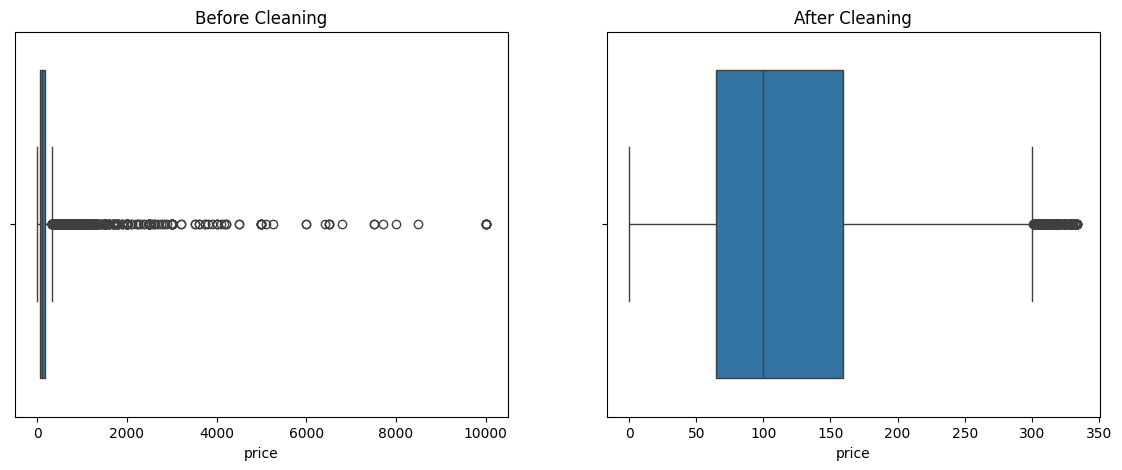

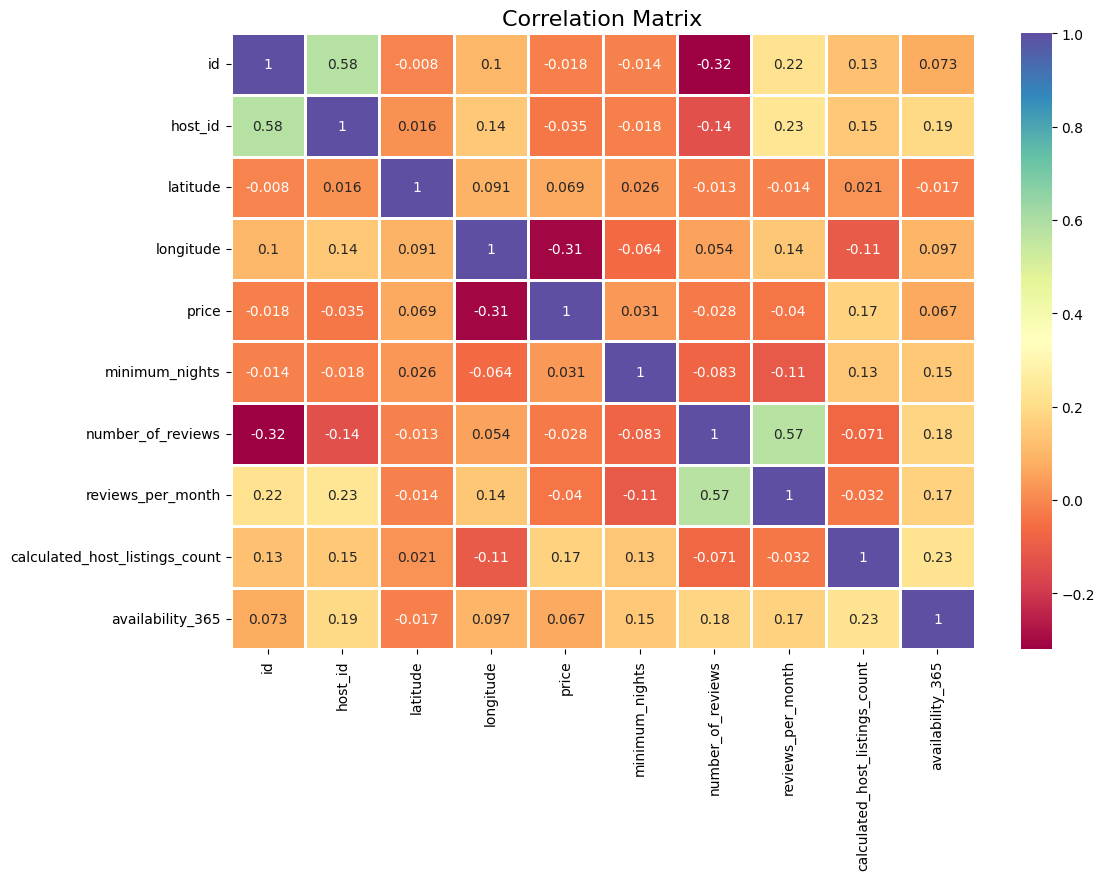

EXECUTIVE DATA CLEANING REPORT
Original Records      : 48895
Final Records         : 45923
Removed Records       : 2972

Cleaning Actions:
✓ Missing Values Handled
✓ Duplicate Records Removed
✓ Outliers Removed
✓ Data Types Standardized

Project Status:
✓ Dataset Ready for Analysis


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EXECUTIVE DATA CLEANING REPORT

BUSINESS INSIGHTS
Average Listing Price      : $119.97
Most Common Room Type      : Entire home/apt
Top Listing Area           : Manhattan

Recommendations:
- Focus marketing in high-demand neighbourhoods
- Promote popular room types
- Monitor price outliers regularly
- Improve host engagement for better reviews


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('AB_NYC_2019.csv.zip')


print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print(df.head())

import plotly.express as px
import plotly.graph_objects as go

total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()

quality_score = (
    (total_cells - missing_cells)
    / total_cells
) * 100

fig = go.Figure()

fig.add_indicator(
    mode="gauge+number",
    value=quality_score,
    title={'text':"Data Quality Score"},
    gauge={
        'axis':{'range':[0,100]},
        'bar':{'thickness':0.4}
    }
)

fig.show()
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='magma'
)

plt.title(
    "Missing Values Heatmap",
    fontsize=16
)

plt.show()
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) > 0:

    fig = px.bar(
        x=missing.index,
        y=missing.values,
        color=missing.values,
        title="Missing Values by Column"
    )

    fig.show()
    df['name'].fillna(
    'Unknown',
    inplace=True
)

df['host_name'].fillna(
    'Unknown',
    inplace=True
)

df['last_review'] = pd.to_datetime(
    df['last_review']
)

df['reviews_per_month'].fillna(
    df['reviews_per_month'].median(),
    inplace=True
)

df['last_review'] = df[
    'last_review'
].fillna(method='ffill')

df.drop_duplicates(
    inplace=True
)
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

sns.boxplot(
    x=df['price']
)

plt.title("Before Cleaning")

Q1 = df['price'].quantile(0.25)

Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

clean_df = df[
    (df['price'] >= lower)
    &
    (df['price'] <= upper)
]

plt.subplot(1,2,2)

sns.boxplot(
    x=clean_df['price']
)

plt.title("After Cleaning")

plt.show()
numeric = clean_df.select_dtypes(
    include='number'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='Spectral',
    linewidths=1
)

plt.title(
    "Correlation Matrix",
    fontsize=16
)

plt.show()
fig = px.sunburst(
    clean_df,
    path=[
        'neighbourhood_group',
        'room_type'
    ],
    title="Listings Hierarchy"
)

fig.show()
fig = px.histogram(
    clean_df,
    x='price',
    nbins=50,
    color='room_type',
    title="Price Distribution"
)

fig.show()
fig = px.scatter(
    clean_df,
    x='availability_365',
    y='price',
    color='room_type',
    size='minimum_nights',
    hover_data=['neighbourhood_group'],
    title='Availability vs Price'
)

fig.show()
avg_price = clean_df.groupby(
    'neighbourhood_group'
)['price'].mean().reset_index()

fig = px.bar(
    avg_price,
    x='neighbourhood_group',
    y='price',
    color='price',
    title='Average Price by Neighbourhood'
)

fig.show()
removed_rows = len(df) - len(clean_df)

print("="*60)
print("EXECUTIVE DATA CLEANING REPORT")
print("="*60)

print(f"Original Records      : {len(df)}")
print(f"Final Records         : {len(clean_df)}")
print(f"Removed Records       : {removed_rows}")

print("\nCleaning Actions:")
print("✓ Missing Values Handled")
print("✓ Duplicate Records Removed")
print("✓ Outliers Removed")
print("✓ Data Types Standardized")

print("\nProject Status:")
print("✓ Dataset Ready for Analysis")
from google.colab import files

clean_df.to_csv(
    "Cleaned_AB_NYC_2019.csv",
    index=False
)

files.download(
    "Cleaned_AB_NYC_2019.csv"
)
print("="*60)
print("EXECUTIVE DATA CLEANING REPORT")
print("="*60)

# ...your report code...

# BUSINESS INSIGHTS
avg_price = clean_df['price'].mean()

most_common_room = clean_df['room_type'].mode()[0]

top_location = clean_df[
    'neighbourhood_group'
].value_counts().idxmax()

print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"Average Listing Price      : ${avg_price:.2f}")
print(f"Most Common Room Type      : {most_common_room}")
print(f"Top Listing Area           : {top_location}")

print("\nRecommendations:")
print("- Focus marketing in high-demand neighbourhoods")
print("- Promote popular room types")
print("- Monitor price outliers regularly")
print("- Improve host engagement for better reviews")

# Download Cleaned Dataset
from google.colab import files

clean_df.to_csv(
    "Cleaned_AB_NYC_2019.csv",
    index=False
)

files.download(
    "Cleaned_AB_NYC_2019.csv"
)
from google.colab import files

clean_df.to_csv(
    "Cleaned_AB_NYC_2019.csv",
    index=False
)

files.download(
    "Cleaned_AB_NYC_2019.csv" )